In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
# 1. Load cleaned data
cleaned_data = pd.read_csv("cleaned_market_data.csv", parse_dates=["Date"])

# 2. Sort properly
cleaned_data = cleaned_data.sort_values(["Ticker", "Date"]).reset_index(drop=True)

# 3. Compute daily returns from Adjusted Close
cleaned_data["Daily Return"] = cleaned_data.groupby("Ticker")["Adj Close"].pct_change()

# 1. Start from cleaned stock price data only
task3_data = cleaned_data[cleaned_data["Ticker"] != "NIFTY50"].copy()

# 2. Sort properly
task3_data = task3_data.sort_values(["Ticker", "Date"]).reset_index(drop=True)

# 3. Compute SMA 50 and SMA 200 using Adj Close
task3_data["SMA_50"] = task3_data.groupby("Ticker")["Adj Close"].transform(
    lambda x: x.rolling(window=50).mean()
)

task3_data["SMA_200"] = task3_data.groupby("Ticker")["Adj Close"].transform(
    lambda x: x.rolling(window=200).mean()
)

# 4. Create comparison columns
task3_data["SMA_50_gt_200"] = task3_data["SMA_50"] > task3_data["SMA_200"]
task3_data["SMA_Diff"] = task3_data["SMA_50"] - task3_data["SMA_200"]

# 5. Inspect
print(task3_data[["Date", "Ticker", "Adj Close", "SMA_50", "SMA_200", "SMA_50_gt_200", "SMA_Diff"]].head(20))
print("\nShape:", task3_data.shape)

         Date      Ticker    Adj Close  SMA_50  SMA_200  SMA_50_gt_200  \
0  2023-01-02  APOLLOHOSP  4411.582520     NaN      NaN          False   
1  2023-01-03  APOLLOHOSP  4447.780762     NaN      NaN          False   
2  2023-01-04  APOLLOHOSP  4390.733887     NaN      NaN          False   
3  2023-01-05  APOLLOHOSP  4386.524902     NaN      NaN          False   
4  2023-01-06  APOLLOHOSP  4345.324707     NaN      NaN          False   
5  2023-01-09  APOLLOHOSP  4365.379883     NaN      NaN          False   
6  2023-01-10  APOLLOHOSP  4423.763672     NaN      NaN          False   
7  2023-01-11  APOLLOHOSP  4318.731934     NaN      NaN          False   
8  2023-01-12  APOLLOHOSP  4317.890625     NaN      NaN          False   
9  2023-01-13  APOLLOHOSP  4293.922363     NaN      NaN          False   
10 2023-01-16  APOLLOHOSP  4253.415039     NaN      NaN          False   
11 2023-01-17  APOLLOHOSP  4281.345215     NaN      NaN          False   
12 2023-01-18  APOLLOHOSP  4298.130859

In [15]:
print("\nFirst rows where both SMAs are available:")
print(
    task3_data[task3_data["SMA_200"].notna()][
        ["Date", "Ticker", "Adj Close", "SMA_50", "SMA_200", "SMA_50_gt_200"]
    ].head(10)
)


First rows where both SMAs are available:
          Date      Ticker    Adj Close       SMA_50      SMA_200  \
199 2023-10-23  APOLLOHOSP  4937.565430  4953.339795  4682.149014   
200 2023-10-25  APOLLOHOSP  4828.621094  4952.275781  4684.234207   
201 2023-10-26  APOLLOHOSP  4729.662598  4949.556904  4685.643616   
202 2023-10-27  APOLLOHOSP  4799.112793  4949.918906  4687.685510   
203 2023-10-30  APOLLOHOSP  4810.588379  4948.109434  4689.805828   
204 2023-10-31  APOLLOHOSP  4788.878418  4946.840645  4692.023596   
205 2023-11-01  APOLLOHOSP  4765.679199  4945.811318  4694.025093   
206 2023-11-02  APOLLOHOSP  4855.546875  4944.904199  4696.184009   
207 2023-11-03  APOLLOHOSP  5120.034180  4949.545146  4700.190520   
208 2023-11-06  APOLLOHOSP  5131.708496  4953.903916  4704.259609   

     SMA_50_gt_200  
199           True  
200           True  
201           True  
202           True  
203           True  
204           True  
205           True  
206           True  
207     

In [16]:
print("\nLatest rows for each ticker:")
print(
    task3_data.groupby("Ticker").tail(1)[
        ["Date", "Ticker", "Adj Close", "SMA_50", "SMA_200", "SMA_50_gt_200"]
    ].sort_values("Ticker")
)


Latest rows for each ticker:
           Date      Ticker    Adj Close       SMA_50      SMA_200  \
490  2024-12-31  APOLLOHOSP  7267.083008  7056.821582  6565.779468   
981  2024-12-31    AXISBANK  1063.790771  1143.203994  1160.504539   
1472 2024-12-31       CIPLA  1512.839355  1486.839053  1493.143644   
1963 2024-12-31    DIVISLAB  6071.155273  5902.236807  4851.418751   
2454 2024-12-31     DRREDDY  1379.749390  1264.833035  1268.538698   
2945 2024-12-31     HCLTECH  1833.876099  1793.461013  1560.203250   
3436 2024-12-31    HDFCBANK   874.603027   877.134784   805.410139   
3927 2024-12-31   ICICIBANK  1271.836426  1283.170957  1189.134199   
4418 2024-12-31        INFY  1825.961792  1824.438064  1650.147101   
4909 2024-12-31   KOTAKBANK   356.798615   351.785809   353.386257   
5400 2024-12-31        SBIN   779.301941   811.958234   795.248052   
5891 2024-12-31   SUNPHARMA  1856.835938  1789.576982  1662.529359   
6382 2024-12-31         TCS  3886.500488  3988.151382  3898.

In [17]:
# Work on a copy
task3_signals = task3_data.copy()

# Keep only rows where both SMAs exist
task3_signals = task3_signals[
    task3_signals["SMA_50"].notna() & task3_signals["SMA_200"].notna()
].copy()

# Previous day's SMA relationship
task3_signals["Prev_SMA_50_gt_200"] = task3_signals.groupby("Ticker")["SMA_50_gt_200"].shift(1)

# Create empty crossover column
task3_signals["Crossover Event"] = None

# Golden Cross: yesterday below/equal, today above
task3_signals.loc[
    (task3_signals["Prev_SMA_50_gt_200"] == False) &
    (task3_signals["SMA_50_gt_200"] == True),
    "Crossover Event"
] = "Golden Cross"

# Death Cross: yesterday above, today below/equal
task3_signals.loc[
    (task3_signals["Prev_SMA_50_gt_200"] == True) &
    (task3_signals["SMA_50_gt_200"] == False),
    "Crossover Event"
] = "Death Cross"

# Inspect only crossover rows
crossover_events = task3_signals[task3_signals["Crossover Event"].notna()].copy()

print(crossover_events[["Date", "Ticker", "SMA_50", "SMA_200", "Crossover Event"]].head(20))
print("\nTotal crossover events found:", len(crossover_events))

           Date     Ticker       SMA_50      SMA_200 Crossover Event
969  2024-12-12   AXISBANK  1159.683914  1160.107807     Death Cross
1468 2024-12-24      CIPLA  1491.658562  1492.173680     Death Cross
1773 2024-03-21   DIVISLAB  3605.613560  3612.500333     Death Cross
1808 2024-05-16   DIVISLAB  3654.339268  3651.739194    Golden Cross
2443 2024-12-13    DRREDDY  1264.220913  1264.871610     Death Cross
2814 2024-06-21    HCLTECH  1314.166545  1314.445877     Death Cross
2834 2024-07-22    HCLTECH  1346.330513  1343.832822    Golden Cross
3303 2024-06-19   HDFCBANK   745.341729   745.312255    Golden Cross
4266 2024-05-22       INFY  1400.643220  1404.050312     Death Cross
4302 2024-07-12       INFY  1433.103972  1431.133860    Golden Cross
4804 2024-07-30  KOTAKBANK   352.002444   351.930856    Golden Cross
4906 2024-12-26  KOTAKBANK   353.180001   353.296665     Death Cross

Total crossover events found: 12


In [18]:
print("\nCrossover count by ticker:")
print(crossover_events.groupby("Ticker")["Crossover Event"].count().sort_values(ascending=False))


Crossover count by ticker:
Ticker
DIVISLAB     2
KOTAKBANK    2
INFY         2
HCLTECH      2
DRREDDY      1
CIPLA        1
AXISBANK     1
HDFCBANK     1
Name: Crossover Event, dtype: int64


In [19]:
print("\nLatest crossover event per ticker:")
latest_crossovers = crossover_events.sort_values(["Ticker", "Date"]).groupby("Ticker").tail(1)
print(latest_crossovers[["Date", "Ticker", "Crossover Event"]].sort_values("Ticker"))


Latest crossover event per ticker:
           Date     Ticker Crossover Event
969  2024-12-12   AXISBANK     Death Cross
1468 2024-12-24      CIPLA     Death Cross
1808 2024-05-16   DIVISLAB    Golden Cross
2443 2024-12-13    DRREDDY     Death Cross
2834 2024-07-22    HCLTECH    Golden Cross
3303 2024-06-19   HDFCBANK    Golden Cross
4302 2024-07-12       INFY    Golden Cross
4906 2024-12-26  KOTAKBANK     Death Cross


In [20]:
# 1. Latest SMA values as of last available date
latest_sma_values = task3_data.groupby("Ticker").tail(1)[
    ["Ticker", "Date", "SMA_50", "SMA_200", "SMA_50_gt_200"]
].copy()

# 2. Current signal based on latest SMA relationship
latest_sma_values["Signal"] = np.where(
    latest_sma_values["SMA_50_gt_200"],
    "Golden Cross",
    "Death Cross"
)

# 3. Latest crossover event per ticker
latest_crossovers = crossover_events.sort_values(["Ticker", "Date"]).groupby("Ticker").tail(1)[
    ["Ticker", "Date", "Crossover Event"]
].copy()

latest_crossovers = latest_crossovers.rename(columns={
    "Date": "Date of Last Crossover",
    "Crossover Event": "Last Crossover Event"
})

# 4. Merge into final signal table
task3_signal_table = latest_sma_values.merge(
    latest_crossovers,
    on="Ticker",
    how="left"
)

# 5. Fill missing crossover info
task3_signal_table["Date of Last Crossover"] = task3_signal_table["Date of Last Crossover"].astype("object")
task3_signal_table["Date of Last Crossover"] = task3_signal_table["Date of Last Crossover"].fillna("No crossover in period")
task3_signal_table["Last Crossover Event"] = task3_signal_table["Last Crossover Event"].fillna("No crossover in period")

# 6. Keep only required columns
task3_signal_table = task3_signal_table[
    ["Ticker", "SMA_50", "SMA_200", "Signal", "Date of Last Crossover", "Last Crossover Event"]
].copy()

# 7. Round SMA columns
task3_signal_table["SMA_50"] = task3_signal_table["SMA_50"].round(2)
task3_signal_table["SMA_200"] = task3_signal_table["SMA_200"].round(2)

# 8. Sort by ticker
task3_signal_table = task3_signal_table.sort_values("Ticker").reset_index(drop=True)

print(task3_signal_table)

        Ticker   SMA_50  SMA_200        Signal  Date of Last Crossover  \
0   APOLLOHOSP  7056.82  6565.78  Golden Cross  No crossover in period   
1     AXISBANK  1143.20  1160.50   Death Cross     2024-12-12 00:00:00   
2        CIPLA  1486.84  1493.14   Death Cross     2024-12-24 00:00:00   
3     DIVISLAB  5902.24  4851.42  Golden Cross     2024-05-16 00:00:00   
4      DRREDDY  1264.83  1268.54   Death Cross     2024-12-13 00:00:00   
5      HCLTECH  1793.46  1560.20  Golden Cross     2024-07-22 00:00:00   
6     HDFCBANK   877.13   805.41  Golden Cross     2024-06-19 00:00:00   
7    ICICIBANK  1283.17  1189.13  Golden Cross  No crossover in period   
8         INFY  1824.44  1650.15  Golden Cross     2024-07-12 00:00:00   
9    KOTAKBANK   351.79   353.39   Death Cross     2024-12-26 00:00:00   
10        SBIN   811.96   795.25  Golden Cross  No crossover in period   
11   SUNPHARMA  1789.58  1662.53  Golden Cross  No crossover in period   
12         TCS  3988.15  3898.83  Gold

In [21]:
task3_signal_table.to_csv("task3_signal_table.csv", index=False)
task3_signal_table.to_excel("task3_signal_table.xlsx", index=False)

print("Saved:")
print("- task3_signal_table.csv")
print("- task3_signal_table.xlsx")

Saved:
- task3_signal_table.csv
- task3_signal_table.xlsx


In [22]:
selected_stocks = ["HDFCBANK", "INFY", "SUNPHARMA"]

chart_data = task3_signals[task3_signals["Ticker"].isin(selected_stocks)].copy()
chart_crossovers = crossover_events[crossover_events["Ticker"].isin(selected_stocks)].copy()

print("Selected chart data sample:")
print(chart_data[["Date", "Ticker", "Adj Close", "SMA_50", "SMA_200"]].head(10))

print("\nCrossover events for selected stocks:")
print(chart_crossovers[["Date", "Ticker", "Crossover Event"]].sort_values(["Ticker", "Date"]))

Selected chart data sample:
           Date    Ticker   Adj Close      SMA_50     SMA_200
3145 2023-10-23  HDFCBANK  732.973022  763.980289  784.030298
3146 2023-10-25  HDFCBANK  728.325195  762.623896  783.753534
3147 2023-10-26  HDFCBANK  712.215881  761.111277  783.370602
3148 2023-10-27  HDFCBANK  715.014343  759.731522  783.072152
3149 2023-10-30  HDFCBANK  722.776978  758.552770  782.837417
3150 2023-10-31  HDFCBANK  718.591492  757.376937  782.594505
3151 2023-11-01  HDFCBANK  717.618164  756.245394  782.339269
3152 2023-11-02  HDFCBANK  718.713135  755.147916  782.159757
3153 2023-11-03  HDFCBANK  722.119995  754.184767  781.942909
3154 2023-11-06  HDFCBANK  727.351807  753.288291  781.731769

Crossover events for selected stocks:
           Date    Ticker Crossover Event
3303 2024-06-19  HDFCBANK    Golden Cross
4266 2024-05-22      INFY     Death Cross
4302 2024-07-12      INFY    Golden Cross


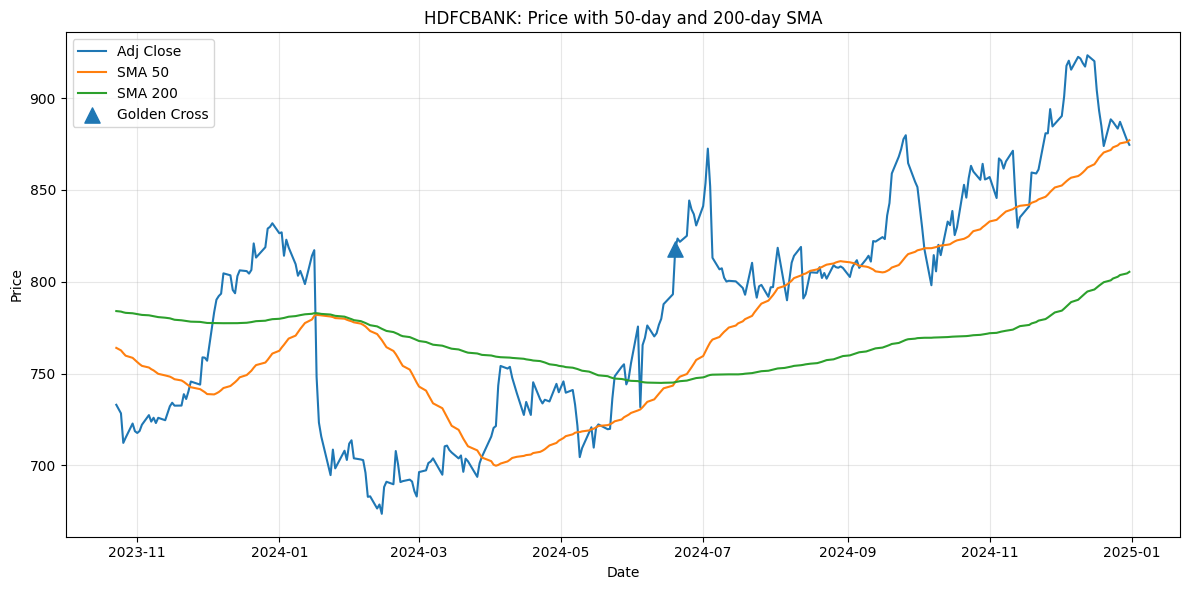

Saved: HDFCBANK_sma_chart.png


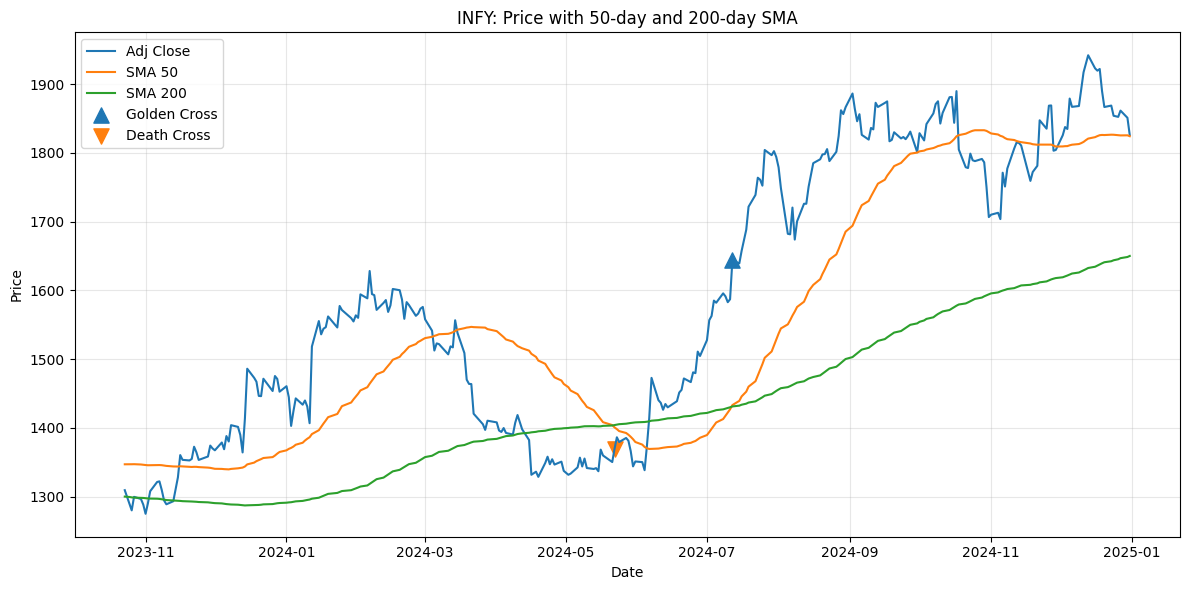

Saved: INFY_sma_chart.png


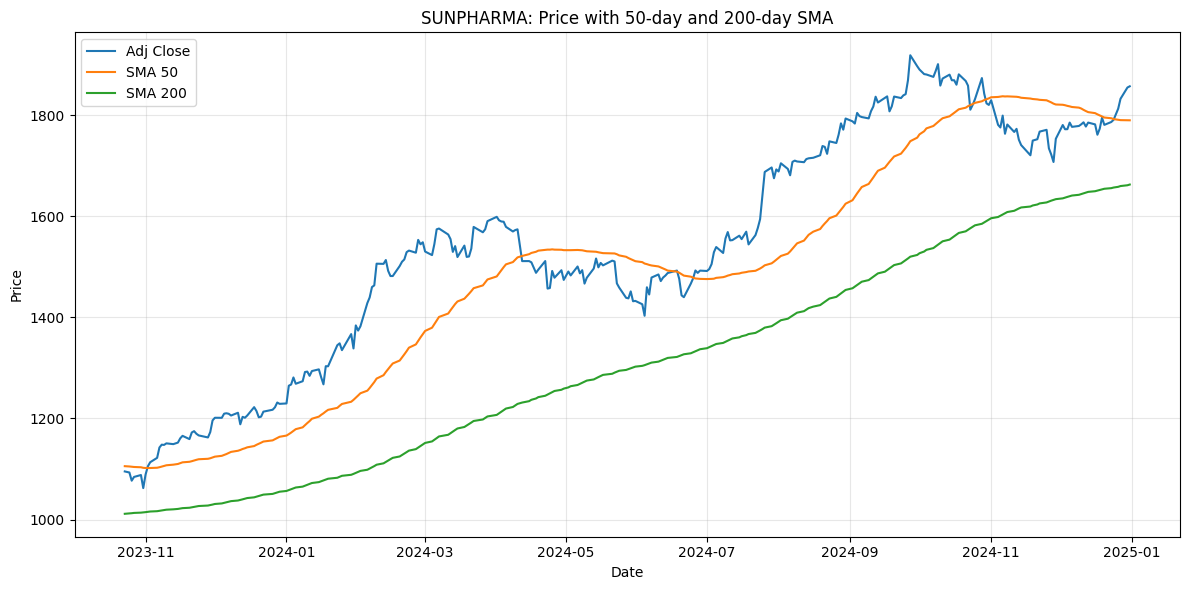

Saved: SUNPHARMA_sma_chart.png


In [23]:
selected_stocks = ["HDFCBANK", "INFY", "SUNPHARMA"]

for ticker in selected_stocks:
    stock_df = task3_signals[task3_signals["Ticker"] == ticker].copy()
    cross_df = crossover_events[crossover_events["Ticker"] == ticker].copy()

    plt.figure(figsize=(12, 6))

    # Price and SMAs
    plt.plot(stock_df["Date"], stock_df["Adj Close"], label="Adj Close")
    plt.plot(stock_df["Date"], stock_df["SMA_50"], label="SMA 50")
    plt.plot(stock_df["Date"], stock_df["SMA_200"], label="SMA 200")

    # Mark crossover events
    golden = cross_df[cross_df["Crossover Event"] == "Golden Cross"]
    death = cross_df[cross_df["Crossover Event"] == "Death Cross"]

    if not golden.empty:
        plt.scatter(golden["Date"], golden["Adj Close"], marker="^", s=120, label="Golden Cross")

    if not death.empty:
        plt.scatter(death["Date"], death["Adj Close"], marker="v", s=120, label="Death Cross")

    plt.title(f"{ticker}: Price with 50-day and 200-day SMA")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    filename = f"{ticker}_sma_chart.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {filename}")

In [24]:
infy_check = task3_signals[task3_signals["Ticker"] == "INFY"][
    ["Date", "Adj Close", "SMA_50", "SMA_200", "Crossover Event"]
].copy()

print(infy_check[infy_check["Crossover Event"].notna()])

# price movement after Golden Cross
golden_date = pd.to_datetime("2024-07-12")

infy_after = infy_check[infy_check["Date"] >= golden_date].copy()
print(infy_after.head(15))
print("\nPrice on crossover date:", infy_after.iloc[0]["Adj Close"])
print("Price about 1 month later:", infy_after.iloc[min(20, len(infy_after)-1)]["Adj Close"])
print("Last available price:", infy_after.iloc[-1]["Adj Close"])

           Date    Adj Close       SMA_50      SMA_200 Crossover Event
4266 2024-05-22  1369.672119  1400.643220  1404.050312     Death Cross
4302 2024-07-12  1643.831055  1433.103972  1431.133860    Golden Cross
           Date    Adj Close       SMA_50      SMA_200 Crossover Event
4302 2024-07-12  1643.831055  1433.103972  1431.133860    Golden Cross
4303 2024-07-15  1639.317627  1439.256663  1432.305632            None
4304 2024-07-16  1657.563721  1445.739436  1433.660650            None
4305 2024-07-18  1688.293945  1452.656047  1435.176522            None
4306 2024-07-19  1721.809204  1459.959583  1436.806528            None
4307 2024-07-22  1738.999023  1467.863936  1438.548507            None
4308 2024-07-23  1764.015381  1476.037954  1440.517808            None
4309 2024-07-24  1761.182373  1484.431165  1442.535682            None
4310 2024-07-25  1752.443481  1492.676904  1444.480350            None
4311 2024-07-26  1804.348999  1501.937214  1446.812580            None
4312 2